In [1]:
# Import Libraries
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load Image
image = Image.open("/content/drive/MyDrive/Artificial Intelligence and Machine Learning]/Barbie.jpg")
image_np = np.array(image)



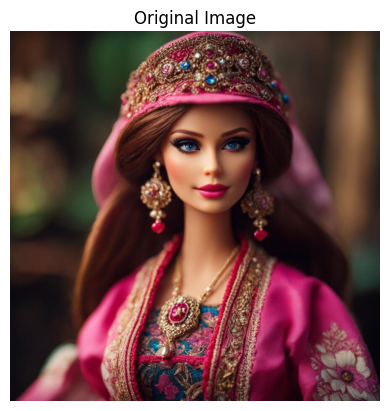

In [3]:
# Display Image
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")
plt.show()

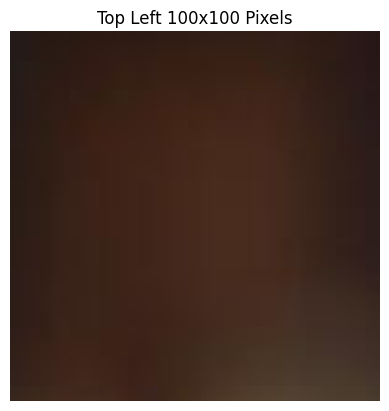

In [4]:
top_left = image_np[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

In [5]:
R = image_np[:, :, 0]
G = image_np[:, :, 1]
B = image_np[:, :, 2]

plt.figure(figsize=(15,5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

(np.float64(-0.5), np.float64(879.5), np.float64(879.5), np.float64(-0.5))

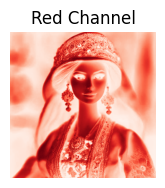

In [6]:
plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")

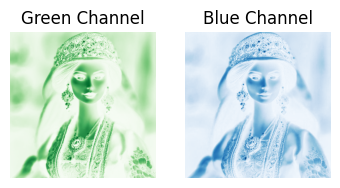

In [7]:
plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

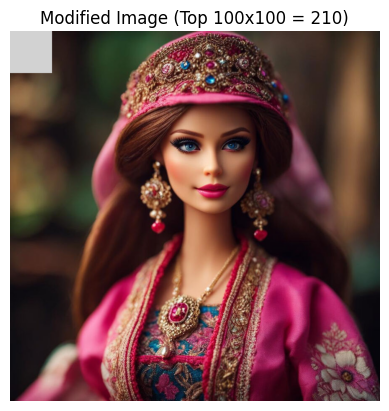

In [8]:
modified_image = image_np.copy()
modified_image[0:100, 0:100] = 210

plt.imshow(modified_image)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

Exercise2

In [9]:
gray_image = Image.open("/content/drive/MyDrive/Artificial Intelligence and Machine Learning]/Road.jpg").convert("L")
gray_np = np.array(gray_image)



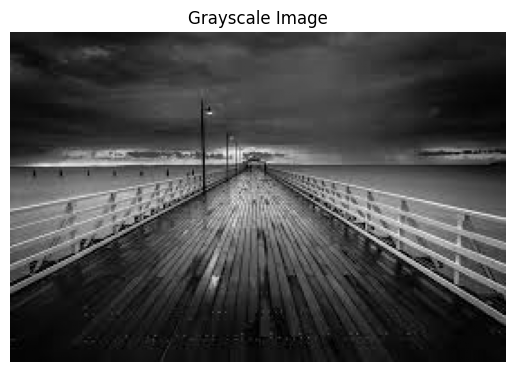

In [10]:
plt.imshow(gray_np, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

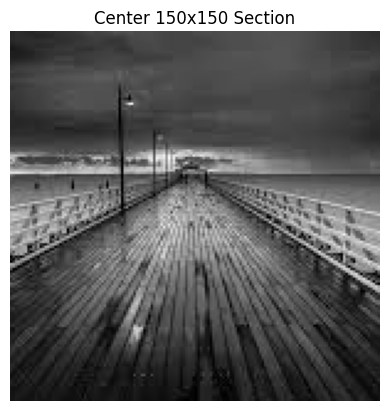

In [11]:
h, w = gray_np.shape
center_crop = gray_np[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(center_crop, cmap="gray")
plt.title("Center 150x150 Section")
plt.axis("off")
plt.show()

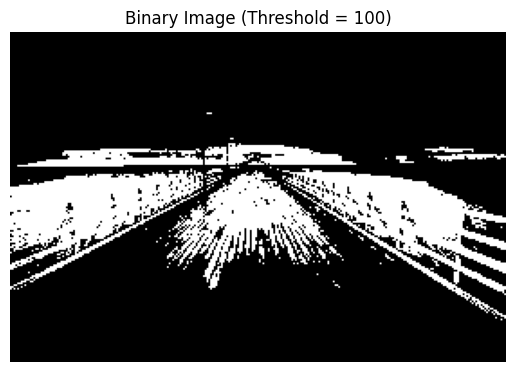

In [12]:
binary_image = np.where(gray_np < 100, 0, 255)

plt.imshow(binary_image, cmap="gray")
plt.title("Binary Image (Threshold = 100)")
plt.axis("off")
plt.show()

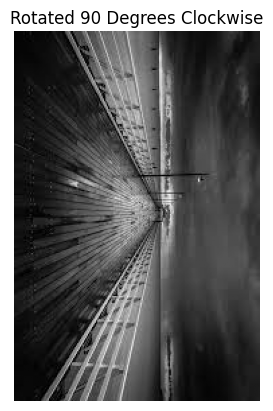

In [13]:
rotated_image = gray_image.rotate(-90, expand=True)

plt.imshow(rotated_image, cmap="gray")
plt.title("Rotated 90 Degrees Clockwise")
plt.axis("off")
plt.show()

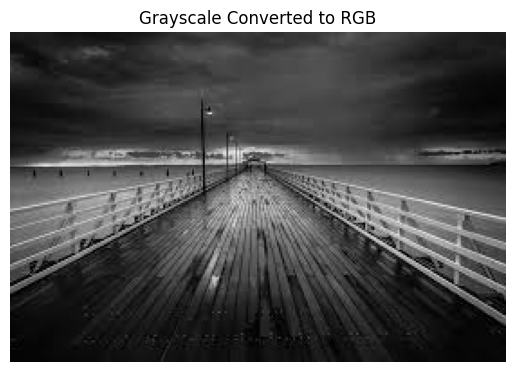

In [14]:
rgb_from_gray = np.stack((gray_np,)*3, axis=-1)

plt.imshow(rgb_from_gray)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

Exercise 3 – PCA for Image Compression (From Scratch)

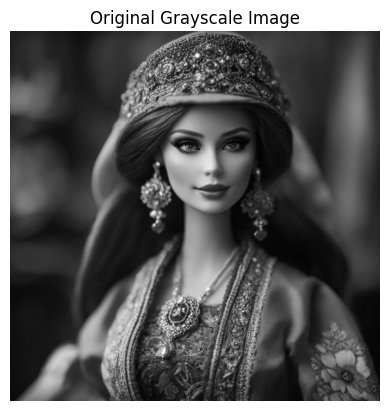

In [15]:
# Load and convert to grayscale
img = Image.open("/content/drive/MyDrive/Artificial Intelligence and Machine Learning]/Barbie.jpg").convert("L")
img_np = np.array(img, dtype=np.float64)

plt.imshow(img_np, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

# Standardize (Center Data)
mean = np.mean(img_np, axis=0)
X_centered = img_np - mean

# Covariance Matrix
cov_matrix = np.cov(X_centered, rowvar=False)

Eigen Decomposition

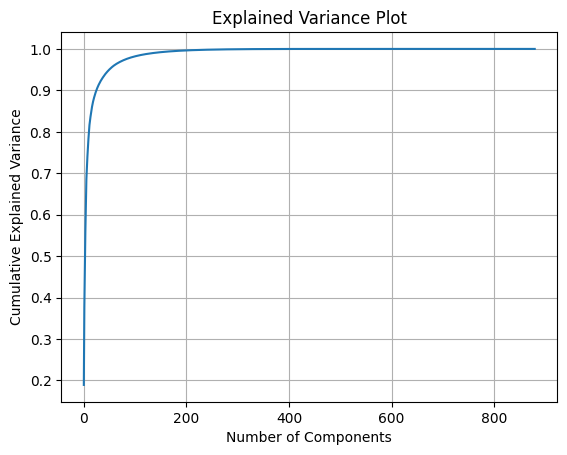

In [16]:
# Compute Eigenvalues & Eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort in Descending Order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Explained Variance Ratio
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot Cumulative Variance
plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.grid()
plt.show()

Reconstruction with Different k Values

In [17]:
def reconstruct_image(X_centered, eigenvectors, k, mean):
    Vk = eigenvectors[:, :k]
    X_reduced = np.dot(X_centered, Vk)
    X_reconstructed = np.dot(X_reduced, Vk.T) + mean
    return X_reconstructed

Experiment with Four Different k Values

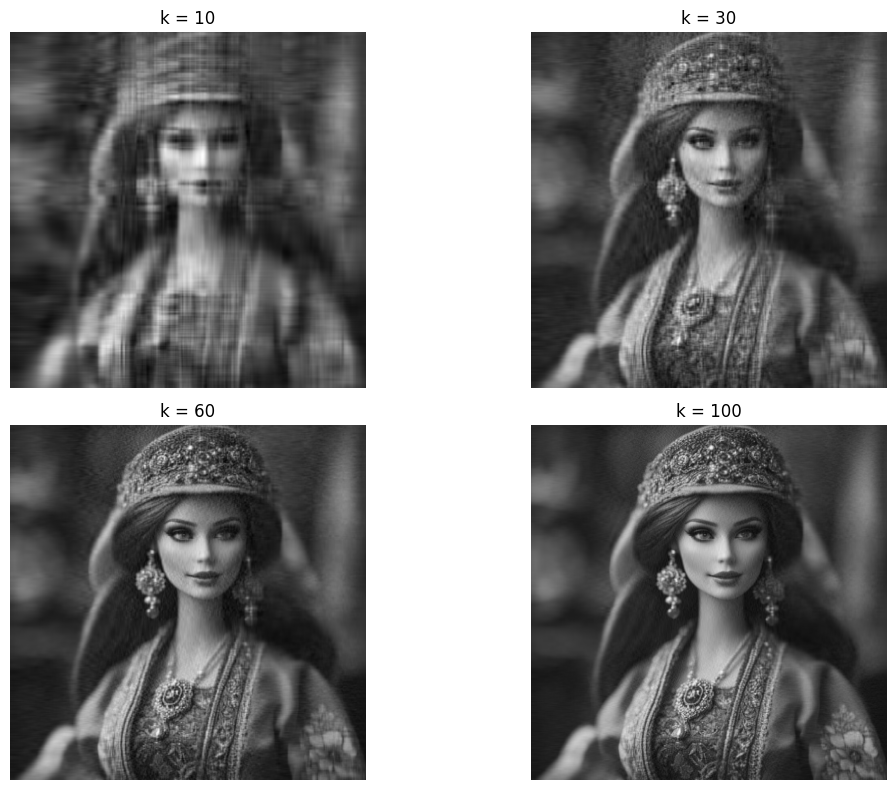

In [18]:
k_values = [10, 30, 60, 100]

plt.figure(figsize=(12,8))

for i, k in enumerate(k_values):
    reconstructed = reconstruct_image(X_centered, eigenvectors, k, mean)

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"k = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()